In [1]:
# - Lets see how regularization effects the quality of classification
# - we will use logistic regression with polinomial features and very the regularization parameter C.
# - we will see how regularization effects the seperating border of classifier and 
# intuitively recoganize under and over fitting
# - we will choose regularization parameter to be numerically close to optimal value
#  via cross-validation and grid-search

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import seaborn as sns
from matplotlib import pyplot as plt
%config InlineBackend.figure_format = "retina"

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_score)
from sklearn.preprocessing import PolynomialFeatures

# What does centered mean

That sentence is describing a common data-preprocessing step called **centering**.

Suppose one of the quality-control test variables originally had values:

| Microchip | Test 1 |
| --------- | ------ |
| A         | 12     |
| B         | 15     |
| C         | 18     |

The mean of Test 1 is:

[
\frac{12+15+18}{3}=15
]

If the data are **centered**, you subtract the mean (15) from every value:

| Microchip | Centered Test 1 |
| --------- | --------------- |
| A         | -3              |
| B         | 0               |
| C         | 3               |

The same process is done separately for each variable (Test 1 and Test 2).

### What does "the average microchip corresponds to a zero value" mean?

After centering:

* A value of **0** means the microchip is exactly at the average for that test.
* A **positive** value means the microchip scored above average.
* A **negative** value means the microchip scored below average.

For example, if a chip has:

* Test 1 = 2.5
* Test 2 = -1.2

then:

* its Test 1 result is 2.5 units above the average Test 1 result,
* its Test 2 result is 1.2 units below the average Test 2 result.

The point **(0, 0)** in the two-dimensional test-result space therefore represents a hypothetical **average microchip**—one whose Test 1 and Test 2 scores are both exactly equal to their respective means.

### Why do this?

Centering makes many statistical methods easier to interpret and compute:

* The origin ((0,0)) becomes the average observation.
* Coefficients in models (e.g., logistic regression) are often easier to interpret.
* Numerical optimization can become more stable.

So in your dataset of 118 microchips, the statement means:

> For each test variable, the mean value has been subtracted from every observation. Therefore, a test value of 0 indicates an average result, positive values indicate above-average results, and negative values indicate below-average results. The point (0,0) represents the average microchip with respect to the two tests.


In [2]:
# dataset of 118 microchips
# there are results of two tests of quality control and information whether the chip went into production
# variables are already centered, ie - column values have had there own mean values subtracted

# DF

DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

#loading data 

data = pd.read_csv(
    DATA_PATH + "microchip_tests.txt",
    header= None,
    names=("test1", "test2", "released")
)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   test1     118 non-null    float64
 1   test2     118 non-null    float64
 2   released  118 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.9 KB


In [3]:
data.head(5)

,test1,test2,released
0,0.051267,0.69956,1
1,-0.092742,0.68494,1
2,-0.213710,0.69225,1
3,-0.375000,0.50219,1
4,-0.513250,0.46564,1


In [4]:
data.tail(5)

,test1,test2,released
113,-0.720620,0.538740,0
114,-0.593890,0.494880,0
115,-0.484450,0.999270,0
116,-0.006336,0.999270,0
117,0.632650,-0.030612,0


In [7]:
X = data.iloc[:,:2].values # all cloumns excluding index no 2
y = data.iloc[:, 2].values # only column with index no 2

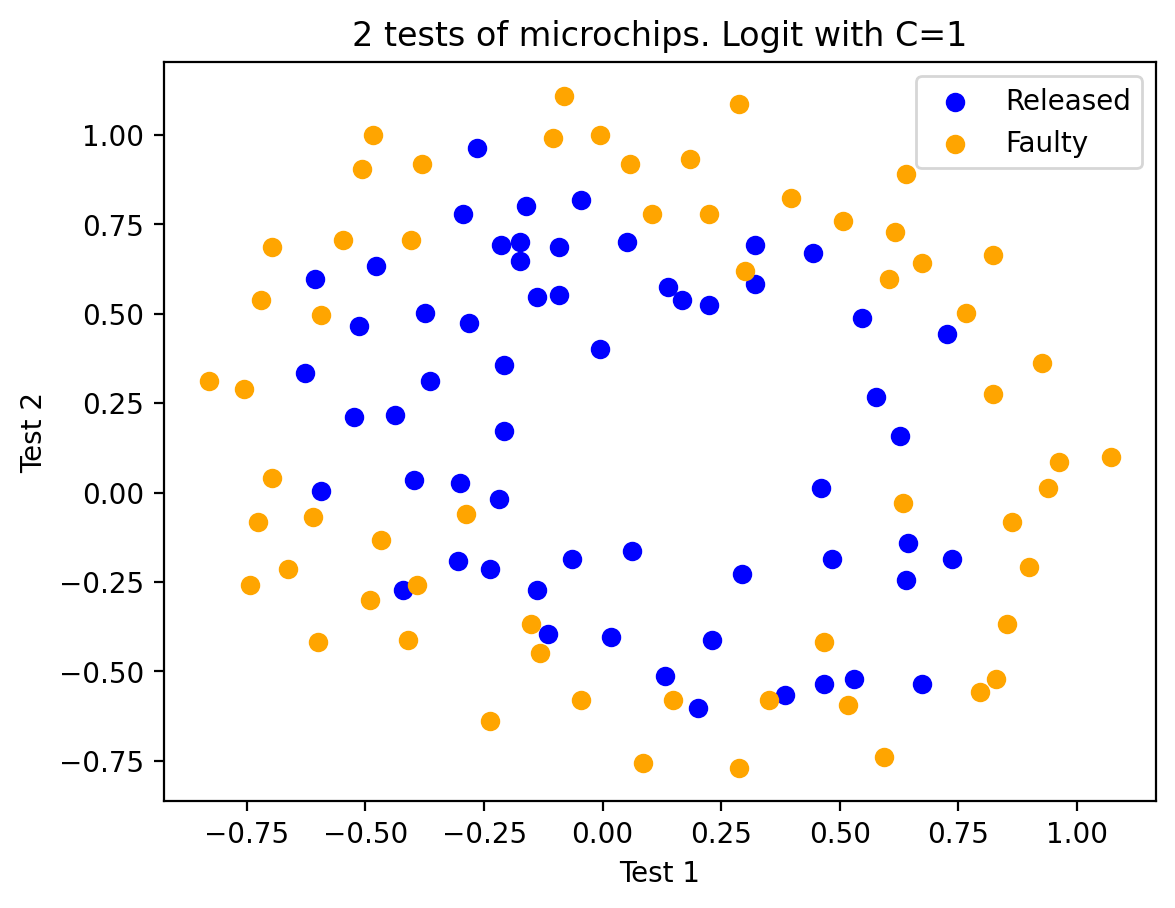

In [8]:
plt.scatter(X[y == 1, 0], X[y == 1, 1], c="blue", label="Released")
plt.scatter(X[y == 0, 0], X[y == 0, 1], c="orange", label="Faulty")
plt.xlabel("Test 1")
plt.ylabel("Test 2")
plt.title("2 tests of microchips. Logit with C=1")
plt.legend()